Using device: cpu
Validation size: 23741

Loading ResNet50 model...
✅ Model loaded successfully

Running inference on validation set...
Processed 20/371 batches (5.39%)
Processed 40/371 batches (10.78%)
Processed 60/371 batches (16.17%)
Processed 80/371 batches (21.56%)
Processed 100/371 batches (26.95%)
Processed 120/371 batches (32.35%)
Processed 140/371 batches (37.74%)
Processed 160/371 batches (43.13%)
Processed 180/371 batches (48.52%)
Processed 200/371 batches (53.91%)
Processed 220/371 batches (59.30%)
Processed 240/371 batches (64.69%)
Processed 260/371 batches (70.08%)
Processed 280/371 batches (75.47%)
Processed 300/371 batches (80.86%)
Processed 320/371 batches (86.25%)
Processed 340/371 batches (91.64%)
Processed 360/371 batches (97.04%)
Processed 371/371 batches (100.00%)

========== PER-CLASS METRICS ==========

Class: short sleeve top
Precision: 0.8957
Recall:    0.8625
F1 Score:  0.8788

Class: long sleeve top
Precision: 0.8151
Recall:    0.7600
F1 Score:  0.7866

Clas

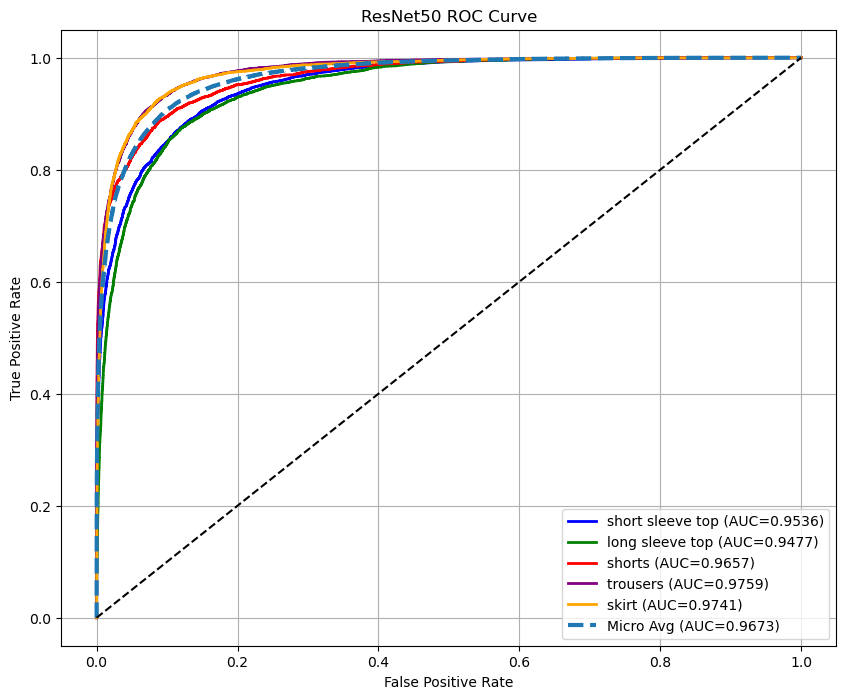


✅ Evaluation Complete


In [2]:
# ============================================================
# RESNET50 EVALUATION SCRIPT (FINAL - LOCAL SETUP)
# ============================================================

import os, json, torch, numpy as np
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_curve, auc

# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================= PATHS (YOUR LOCAL STRUCTURE) =================
BASE_DIR = "/Users/harshsinha/Desktop/iiitbSemester/sem6/vr/evaluation"

VAL_IMG = os.path.join(BASE_DIR, "validation/images")
VAL_ANN = os.path.join(BASE_DIR, "validation/annos")

MODEL_PATH = os.path.join(BASE_DIR, "pthFiles/RESNETTransfer.pth")

# ================= LABEL MAP =================
LABEL_MAP = {
    "short sleeve top": 0,
    "long sleeve top": 1,
    "shorts": 2,
    "trousers": 3,
    "skirt": 4
}

CLASS_NAMES = list(LABEL_MAP.keys())
NUM_CLASSES = 5

# ================= DATASET =================
class DeepFashionDataset(Dataset):

    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.files = os.listdir(ann_dir)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        file = self.files[idx]
        json_path = os.path.join(self.ann_dir, file)
        img_path = os.path.join(self.img_dir, file.replace(".json", ".jpg"))

        # Load image
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            return torch.zeros((3,224,224)), torch.zeros(NUM_CLASSES)

        if self.transform:
            image = self.transform(image)

        # Load labels
        with open(json_path) as f:
            data = json.load(f)

        target = torch.zeros(NUM_CLASSES)

        for key, val in data.items():
            if key.startswith("item"):
                cat = val["category_name"]
                if cat in LABEL_MAP:
                    target[LABEL_MAP[cat]] = 1.0

        return image, target

# ================= TRANSFORM (IMPORTANT) =================
# SAME AS TRAINING VAL TRANSFORM
val_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.CenterCrop((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ================= DATA LOADER =================
val_dataset = DeepFashionDataset(VAL_IMG, VAL_ANN, val_tf)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0   # ✅ FIXED
)

print("Validation size:", len(val_dataset))

# ================= MODEL =================
print("\nLoading ResNet50 model...")

model = models.resnet50(weights=None)  # IMPORTANT: no pretrained weights
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("✅ Model loaded successfully")

# ================= INFERENCE =================
all_preds, all_labels, all_probs = [], [], []

print("\nRunning inference on validation set...")

total_batches = len(val_loader)

with torch.no_grad():
    for i, (images, labels) in enumerate(val_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.numpy())

        # 🔥 Controlled printing (every 20 batches)
        if (i + 1) % 20 == 0 or (i + 1) == total_batches:
            percent = (i + 1) / total_batches * 100
            print(f"Processed {i+1}/{total_batches} batches ({percent:.2f}%)")

# Stack everything
all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# ================= PER-CLASS METRICS =================
print("\n========== PER-CLASS METRICS ==========")

for i, cls in enumerate(CLASS_NAMES):
    precision = precision_score(all_labels[:, i], all_preds[:, i], zero_division=0)
    recall    = recall_score(all_labels[:, i], all_preds[:, i], zero_division=0)
    f1        = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)

    print(f"\nClass: {cls}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

# ================= OVERALL METRICS =================
micro_f1 = f1_score(all_labels, all_preds, average='micro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n========== OVERALL ==========")
print(f"Micro F1: {micro_f1:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

# ================= ROC CURVE =================
print("\nPlotting ROC Curve...")

plt.figure(figsize=(10,8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Per-class ROC
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.4f})")

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.plot(fpr_micro, tpr_micro, linestyle='--', lw=3,
         label=f"Micro Avg (AUC={roc_auc_micro:.4f})")

# Formatting
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 ROC Curve")
plt.legend()
plt.grid()

plt.savefig(os.path.join(BASE_DIR, "resnet_eval_roc.png"))
plt.show()

print("\n✅ Evaluation Complete")